In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
N = 641
dx = 100.0 / (N - 1.0)

cfl = 0.5
advection = 1.0
sigma = 0.8
max_time = 50.0

In [23]:
def apply_absorbing_bc(u, advection):
    """Apply proper absorbing boundary conditions"""
    # # For absorbing/outflow boundaries:
    u[0] = u[2]  # Linear extrapolation for i=-1
    u[1] = u[2]  # Linear extrapolation for i=0
    u[-2] = u[-3]  # Linear extrapolation for i=N-2
    u[-1] = u[-3]  # Linear extrapolation for i=N-1

    # if advection > 0:
    #     # Right boundary: outflow - use 3rd order extrapolation
    #     # Based on characteristic: new value = old value shifted by CFL
    #     u[-2] = 3*u[-3] - 3*u[-4] + u[-5]  # Cubic extrapolation
    #     u[-1] = 3*u[-2] - 3*u[-3] + u[-4]

    #     # Left boundary: inflow - set to zero (no incoming wave)
    #     u[0] = 0.0
    #     u[1] = 0.0

    # else:  # A_Speed < 0
    #     # Left boundary: outflow
    #     u[1] = 3*u[2] - 3*u[3] + u[4]
    #     u[0] = 3*u[1] - 3*u[2] + u[3]

    #     # Right boundary: inflow
    #     u[-2] = 0.0
    #     u[-1] = 0.0

    return u


def apply_sponge_layer(u, damping, tau):
    """Apply sponge layer damping"""
    return u * np.exp(-damping * tau)

In [24]:
grid = np.linspace(0.0, (N-1)*dx, N)


# Initial condition (Gaussian pulse)
def gaussian_pulse(grid, center, width):
    return np.exp(-((grid - center) / width)**2)


center = 20.0
width = 5.0

u_exact = gaussian_pulse(grid, center=center, width=width)
u_rusanov = u_exact.copy()
u = np.zeros(N + 4)
u[2:N + 2] = u_rusanov

In [25]:
# Add ghost points
N_total = N + 4  # 2 ghost points on each side
u_new = np.zeros(N_total)
X_ext = np.zeros(N_total)

# Initialize with ghost points
X_ext[2:N+2] = grid  # Interior points
# Extend x-coordinates for ghost points
X_ext[0] = grid[0] - 2*dx
X_ext[1] = grid[0] - dx
X_ext[-2] = grid[-1] + dx
X_ext[-1] = grid[-1] + 2*dx

sponge_width = 15 * dx
damping = np.zeros(N_total)
x_left = X_ext[2]
x_right = X_ext[N+1]
strength = 2.0

for i in range(N_total):
    if X_ext[i] < x_left + sponge_width:
        xi = (x_left + sponge_width - X_ext[i]) / sponge_width
        damping[i] = strength * xi**2
    elif X_ext[i] > x_right - sponge_width:
        xi = (X_ext[i] - (x_right - sponge_width)) / sponge_width
        damping[i] = strength * xi**2


In [26]:
time = 0.0

cfl2 = cfl * cfl
cfl3 = cfl2 * cfl
omega = (4.0 * cfl2 + 1.0) * (4.0 - cfl2) / 5.0

while time <= max_time:
    dt = dx * cfl / advection
    time += dt

    u_rusanov_new = np.zeros_like(u_rusanov)
    
    i = np.arange(2, N - 2)
    
    u_rusanov_new[i] = (
        u_rusanov[i]
        - cfl/12.0 * (-u_rusanov[i+2] + 8.0*u_rusanov[i+1] - 8.0*u_rusanov[i-1] + u_rusanov[i-2])
        + cfl2/8.0 * (u_rusanov[i+2] - 2.0*u_rusanov[i] + u_rusanov[i-2])
        - cfl3/12.0 * (u_rusanov[i+2] - 2.0*u_rusanov[i+1] + 2.0*u_rusanov[i-1] - u_rusanov[i-2])
        - omega/24.0 * (u_rusanov[i+2] - 4.0*u_rusanov[i+1] + 6.0*u_rusanov[i] 
                       - 4.0*u_rusanov[i-1] + u_rusanov[i-2])
    )

    u_rusanov = u_rusanov_new


    # u = apply_absorbing_bc(u, advection)    
    # u = apply_boundary_conditions(u, method='absorbing')
    u_new = np.zeros_like(u)

    i = np.arange(2, N)    
    u_new[i] = (
        sigma * u[i]
        + (1.0 - sigma) * 0.5 * (u[i+1] + u[i-1])
        - 0.5 * cfl * (u[i+1] - u[i-1])
        + 0.5 * cfl2 * (u[i+1] - 2.0 * u[i] + u[i-1])
        - 1.0/6.0 * (
            -(1.0 - sigma)/4.0 *
                (u[i-2] - 16.0*u[i-1] + 30.0*u[i] - 16.0*u[i+1] + u[i+2])
            + 0.5 * advection * dt / dx *
                (u[i-2] - 2.0*u[i-1]  + 2.0*u[i+1] - u[i+2])
            + 0.25 * advection**2 * dt**2 / dx**2 *
                (u[i-2] - 4.0*u[i-1]  + 6.0*u[i] - 4.0*u[i+1]  + u[i+2])
        )
    )
    
    # u_new = apply_sponge_layer(u_new, damping, dt)

    u = u_new

In [27]:
u_exact = gaussian_pulse(grid, center=time * advection + center, width=width)
error_rusanov = u_rusanov - u_exact
error = u[2:N+2] - u_exact

UMax = np.max(error_rusanov) * dx
ULeb = np.sum(error_rusanov) * dx
ULeb2 = np.sqrt(np.sum(error_rusanov**2) * dx)

UMax1 = np.max(error) * dx
ULeb1 = np.sum(error) * dx
ULeb12 = np.sqrt(np.sum(error**2) * dx)

In [28]:
print("=" * 60)
print("=" * 60)
print(f"\nRusanov Scheme Errors:")
print(f"  L∞ (max) error: {UMax:.4e}")
print(f"  L1 error:       {ULeb:.4e}")
print(f"  L2 error:       {ULeb2:.4e}")

print(f"\nAuthor Scheme Errors:")
print(f"  L∞ (max) error: {UMax1:.4e}")
print(f"  L1 error:       {ULeb1:.4e}")
print(f"  L2 error:       {ULeb12:.4e}")

print(f"\nScheme Comparison (Rusanov/Author):")
print(f"  L∞ ratio: {UMax/UMax1:.4f}")
print(f"  L1 ratio:  {ULeb/ULeb1:.4f}")
print(f"  L2 ratio:  {ULeb2/ULeb12:.4f}")

print(f"\nParameters:")
print(f"  Grid points: {N}")
print(f"  Spatial step: {dx:.6f}")
print(f"  CFL number: {cfl:.2f}")
print(f"  Final time: {time:.2f}")
print("=" * 60)


Rusanov Scheme Errors:
  L∞ (max) error: 1.6581e-05
  L1 error:       -8.5331e-08
  L2 error:       3.6699e-04

Author Scheme Errors:
  L∞ (max) error: 2.4742e-04
  L1 error:       -5.7866e-08
  L2 error:       3.9315e-03

Scheme Comparison (Rusanov/Author):
  L∞ ratio: 0.0670
  L1 ratio:  1.4746
  L2 ratio:  0.0933

Parameters:
  Grid points: 641
  Spatial step: 0.156250
  CFL number: 0.50
  Final time: 50.08


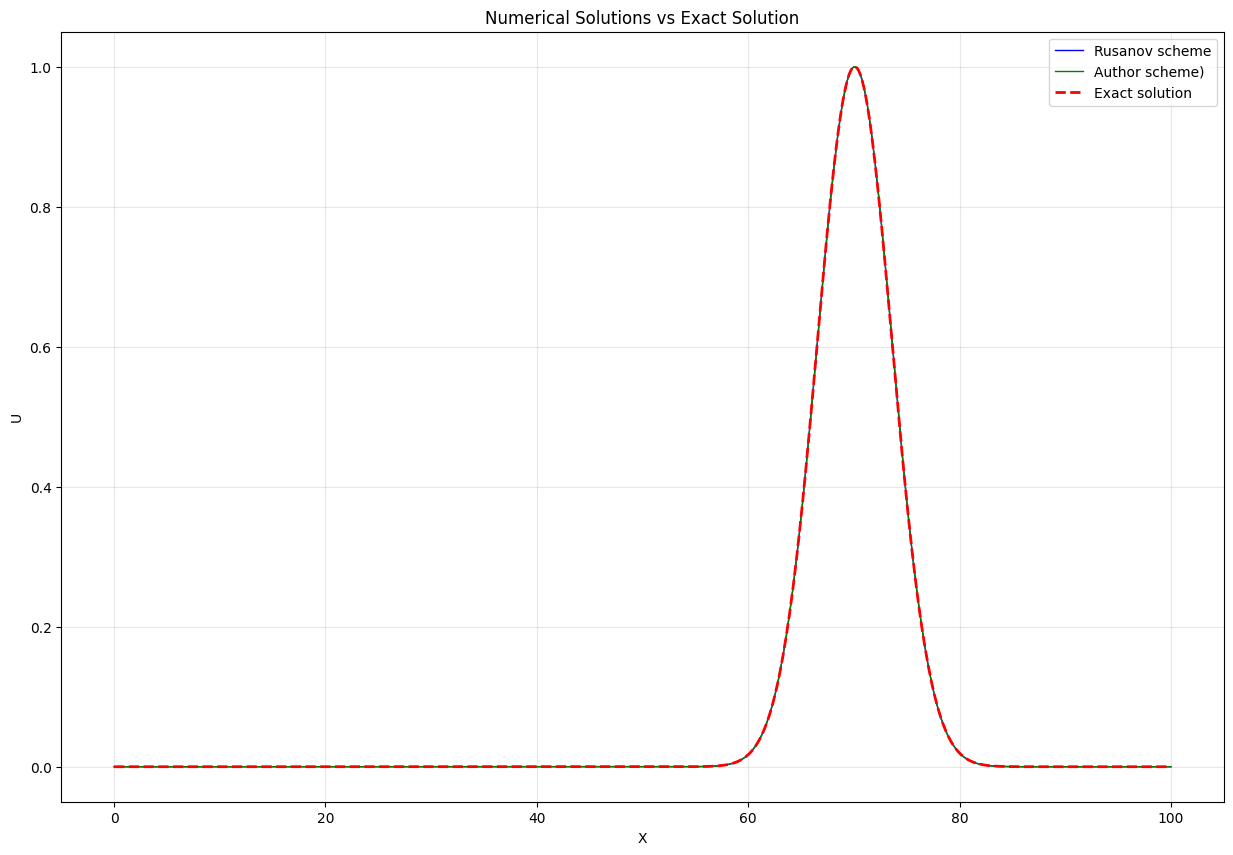

In [29]:
plt.figure(figsize=(15, 10))
plt.plot(grid, u_rusanov, 'b-', linewidth=1, label='Rusanov scheme')
plt.plot(grid, u[2:-2], 'g-', linewidth=1, label='Author scheme)')
plt.plot(grid, u_exact, 'r--', linewidth=2, label='Exact solution')
plt.xlabel('X')
plt.ylabel('U')
plt.title('Numerical Solutions vs Exact Solution')
plt.legend()
plt.grid(True, alpha=0.3)


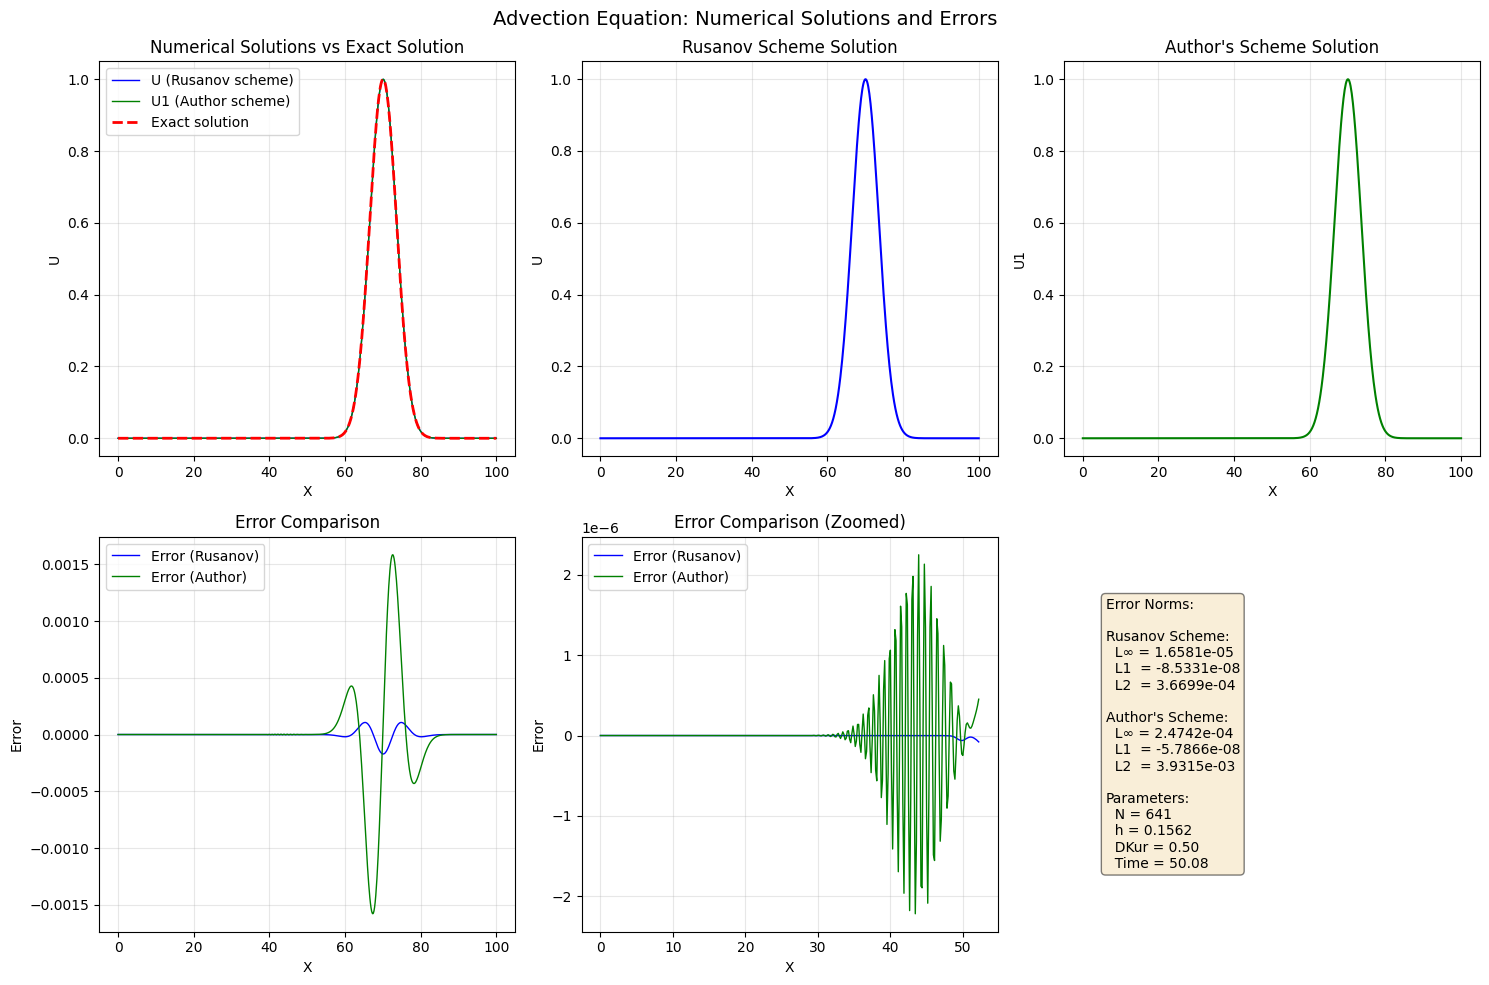

In [30]:

# Create a figure with multiple subplots
plt.figure(figsize=(15, 10))

# Plot 1: Numerical solutions and exact solution
plt.subplot(2, 3, 1)
plt.plot(grid, u_rusanov, 'b-', linewidth=1, label='U (Rusanov scheme)')
plt.plot(grid, u[2:-2], 'g-', linewidth=1, label='U1 (Author scheme)')
plt.plot(grid, u_exact, 'r--', linewidth=2, label='Exact solution')
plt.xlabel('X')
plt.ylabel('U')
plt.title('Numerical Solutions vs Exact Solution')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Rusanov scheme solution
plt.subplot(2, 3, 2)
plt.plot(grid, u_rusanov, 'b-', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('U')
plt.title('Rusanov Scheme Solution')
plt.grid(True, alpha=0.3)

# Plot 3: Author's scheme solution
plt.subplot(2, 3, 3)
plt.plot(grid, u[2:-2], 'g-', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('U1')
plt.title("Author's Scheme Solution")
plt.grid(True, alpha=0.3)

# Plot 4: Error comparison
plt.subplot(2, 3, 4)
plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Error (Rusanov)')
plt.plot(grid, error, 'g-', linewidth=1, label='Error (Author)')
plt.xlabel('X')
plt.ylabel('Error')
plt.title('Error Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Zoomed error comparison (first 100 points)
plt.subplot(2, 3, 5)
n_el = int(advection * max_time / dx) + 15
plt.plot(grid[:n_el], error_rusanov[:n_el], 'b-', linewidth=1, label='Error (Rusanov)')
plt.plot(grid[:n_el], error[:n_el], 'g-', linewidth=1, label='Error (Author)')
plt.xlabel('X')
plt.ylabel('Error')
plt.title('Error Comparison (Zoomed)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: Error norms text display
plt.subplot(2, 3, 6)
plt.axis('off')
textstr = '\n'.join((
    f'Error Norms:',
    f'',
    f'Rusanov Scheme:',
    f'  L∞ = {UMax:.4e}',
    f'  L1  = {ULeb:.4e}',
    f'  L2  = {ULeb2:.4e}',
    f'',
    f"Author's Scheme:",
    f'  L∞ = {UMax1:.4e}',
    f'  L1  = {ULeb1:.4e}',
    f'  L2  = {ULeb12:.4e}',
    f'',
    f'Parameters:',
    f'  N = {N}',
    f'  h = {dx:.4f}',
    f'  DKur = {cfl:.2f}',
    f'  Time = {time:.2f}'
))
plt.text(0.1, 0.5, textstr, fontsize=10, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Advection Equation: Numerical Solutions and Errors', fontsize=14)
plt.tight_layout()

plt.show()